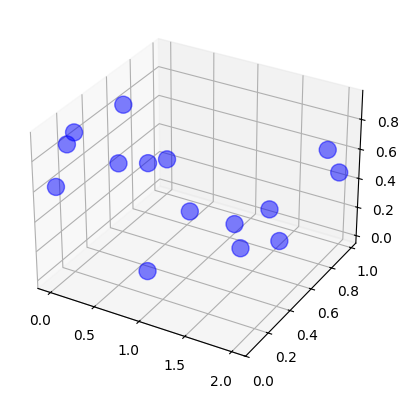

[[ 2.00000000e+00  9.80297990e-01  4.59890043e-01]
 [ 1.00000000e+00  8.43678761e-01  1.35660835e-02]
 [-7.74859240e-11  6.29820713e-01  8.08236334e-01]
 [ 2.00000000e+00  6.65861081e-02  5.79391712e-01]
 [ 2.00000000e+00  4.12788416e-01  3.81526048e-01]
 [ 2.00000000e+00  6.66086213e-02  5.79398699e-01]
 [ 2.97785726e-11  5.78532880e-01  4.41156314e-01]
 [ 5.45519455e-12  7.59535022e-02  6.10435661e-01]
 [ 2.00000000e+00  3.16025259e-01  6.56805544e-01]
 [ 1.00000000e+00  9.34458775e-02  9.25246581e-01]
 [-1.93949468e-11  1.71546064e-01  8.28091235e-01]
 [-6.13427678e-11  2.29589514e-01  8.69807986e-01]]


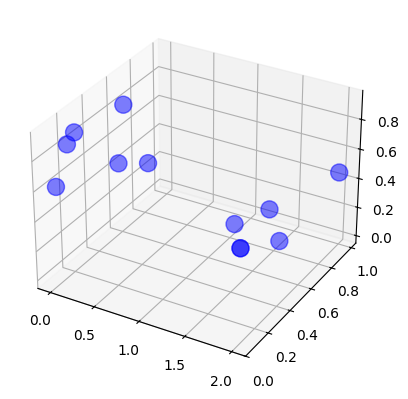

In [7]:
from convex_hull import random_vertices_by_fiber
from convex_hull import generate_convex_hull
from get_cpoints import h_to_v_rep
import matplotlib.pyplot as plt

k = 5 # Como parámetro de número de vertices por slice

vertices = random_vertices_by_fiber([0,1,2], 2, k)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(vertices[:, 0], vertices[:, 1], vertices[:, 2], 
           c='blue', s=150, label='Puntos Input', alpha=0.5)
plt.show()

A,b = generate_convex_hull(vertices)

verts = h_to_v_rep(A, b)

print(verts)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(verts[:, 0], verts[:, 1], verts[:, 2], 
           c='blue', s=150, label='Puntos ConvexHull', alpha=0.5)
plt.show()

slice: 0
[[ 2.00000000e+00  9.80297990e-01  4.59890043e-01]
 [ 1.00000000e+00  8.43678761e-01  1.35660835e-02]
 [-7.74859240e-11  6.29820713e-01  8.08236334e-01]
 [ 2.00000000e+00  6.65861081e-02  5.79391712e-01]
 [ 2.00000000e+00  4.12788416e-01  3.81526048e-01]]


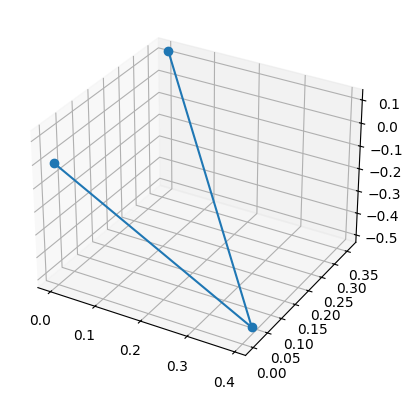

[[ 0.          0.39366359  0.011368  ]
 [ 0.          0.04318632  0.35971429]
 [ 0.         -0.52004829  0.13086967]
 [ 0.         -0.17384598 -0.066996  ]
 [ 0.          0.25704436 -0.43495596]]
[0.         0.02573145 0.01530103]
slice: 1
[[2.00000000e+00 6.66086213e-02 5.79398699e-01]
 [2.97785726e-11 5.78532880e-01 4.41156314e-01]
 [5.45519455e-12 7.59535022e-02 6.10435661e-01]
 [2.00000000e+00 3.16025259e-01 6.56805544e-01]
 [1.00000000e+00 9.34458775e-02 9.25246581e-01]]


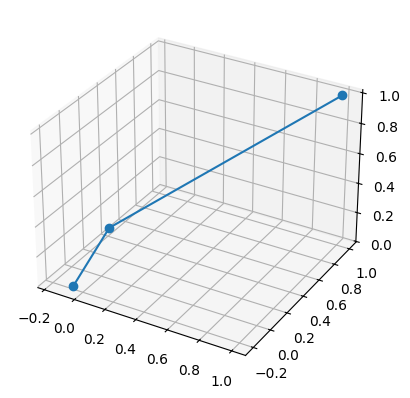

[[ 1.         -0.15950461 -0.06320986]
 [ 1.          0.35241965 -0.20145225]
 [ 1.          0.08991203  0.01419698]
 [ 1.         -0.13266735  0.28263802]
 [ 1.         -0.15015973 -0.0321729 ]]
[1.         0.01067763 0.00140471]
slice: 2
[[-1.93949468e-11  1.71546064e-01  8.28091235e-01]
 [-6.13427678e-11  2.29589514e-01  8.69807986e-01]]


IndexError: index 2 is out of bounds for axis 0 with size 2

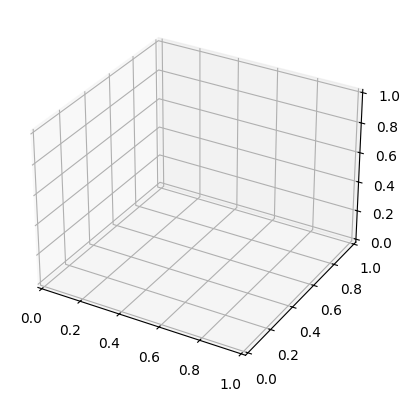

In [8]:
from get_cpoints import get_points
from get_cpoints import ordenar_vertices
import numpy as np

for z, i in enumerate(range(0, len(verts), k)):
    grupo = verts[i:i+k]
    print("slice:", z)
    print(grupo)

    ordenados = ordenar_vertices(grupo)

    z_col = np.full((len(ordenados), 1), z)
    ordenados_3d = np.hstack((z_col, ordenados))
    
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    plt.plot(ordenados_3d[0], ordenados_3d[1], ordenados_3d[2], marker="o")
    plt.show()
    print(ordenados_3d)

    candidato = get_points(ordenados_3d, z)
    print(candidato)